In [1]:
from sklearn.decomposition import PCA
import umap
import torch
import pandas as pd

## PCA reduction of Phoneme Output

We reverse the final output layer's weights. Instead of:

hidden (256) -> phonemes (50)

We take the phonemes and produce a 256-dimensional vector
representing each phoneme. Then we reduce to 3 dimensions using PCA.

In [2]:
from data_sb import make_encoders

# Recreate our encoder so we can put labels on the graph
hparams = {
    "word_outputs": 8000,
    "phone_outputs": 51,
    "supported_languages": ["fr", "en"],
    "word_files": {"fr": "data/words_fr.csv", "en": "data/words_en.csv"},
    "phon_files": {"fr": "data/phonemes_fr.csv", "en": "data/phonemes_en.csv"},
}
make_encoders(hparams)
phone_encoder = hparams["phon_encoder"]

In [3]:
def reduce_pca(model_file, phone_encoder, pca_components=3, normalize=False):
    """Takes a model file and produces a mapping from phoneme -> PCA components"""

    # Load model file and create phoneme -> hidden mapping, ignoring first "unk" token
    state_dict = torch.load(model_file, map_location="cpu")
    phone_mapping = state_dict["phone_out.weight"][1:]

    if normalize:
        phone_mapping = phone_mapping / phone_mapping.norm(dim=1, keepdim=True)

    # Reduce dimensions
    phone_pca = PCA(pca_components).fit_transform(phone_mapping)

    # Load labels and attach to component vectors
    phones = list(phone_encoder.lab2ind)[1:]
    phone2pca = [{"phoneme": p, **{f"pca_{i}": c for i, c in enumerate(pca)}} for p, pca in zip(phones, phone_pca)]

    return pd.DataFrame(phone2pca)

In [4]:
# Put everything together to generate phone2pca mapping
#model_file = "bilingual_networks/results/20fr20fr/save/CKPT+2025-11-11+11-40-05+00/model.ckpt"
#model_file = "bilingual_networks/results/20fr20en/save/CKPT+2025-11-11+11-59-10+00/model.ckpt"
model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-11+11-48-28+00/model.ckpt"
phone2pca = reduce_pca(model_file, phone_encoder)

In [5]:
phone2pca.head()

,phoneme,pca_0,pca_1,pca_2
0,a,0.612412,0.488699,0.431316
1,aw,0.861602,0.088768,0.011327
2,b,-0.728719,0.556903,-0.784927
3,d,-0.722448,0.539928,-0.254903
4,dʒ,-0.840541,-0.159615,0.374693


In [6]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = px.scatter_3d(phone2pca, x='pca_0', y='pca_1', z='pca_2', text='phoneme')
fig.show()

In [7]:
def reduce_umap(model_file, phone_encoder, umap_components=3, normalize=True):
    """Takes a model file and produces a mapping from phoneme -> UMAP components"""

    # Load model file and create phoneme -> hidden mapping, ignoring first "unk" token
    state_dict = torch.load(model_file, map_location="cpu")
    phone_mapping = state_dict["phone_out.weight"][1:]

    if normalize:
        phone_mapping = phone_mapping / phone_mapping.norm(dim=1, keepdim=True)

    # Reduce dimensions
    phone_umap = umap.UMAP(n_components=umap_components, metric='cosine').fit_transform(phone_mapping)

    # Load labels and attach to component vectors
    phones = list(phone_encoder.lab2ind)[1:]
    phone2umap = [{"phoneme": p, **{f"umap_{i}": c for i, c in enumerate(u)}} for p, u in zip(phones, phone_umap)]

    return pd.DataFrame(phone2umap)

In [8]:
model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-11+11-48-28+00/model.ckpt"
phone2umap = reduce_umap(model_file, phone_encoder)

In [9]:
#fig = px.scatter_3d(phone2umap, x='umap_0', y='umap_1', z='umap_2', text='phoneme')
fig = px.scatter(phone2umap, x='umap_0', y='umap_1', text='phoneme')
fig.update_traces(textposition='top center')
fig.show()

In [10]:
#model_file = "bilingual_networks/results/20fr20fr05en95/save/CKPT+2025-11-11+11-48-28+00/model.ckpt"
model_file = "bilingual_networks/results/20fr20en/save/CKPT+2025-11-11+11-59-10+00/model.ckpt"
phone2umap = reduce_umap(model_file, phone_encoder)

In [11]:
#fig = px.scatter_3d(phone2umap, x='umap_0', y='umap_1', z='umap_2', text='phoneme')
fig = px.scatter(phone2umap, x='umap_0', y='umap_1', text='phoneme')
fig.update_traces(textposition='top center')
fig.show()

In [12]:
# Looks like all the FR-only phonemes cluster at one side
fr_phonemes = set(pd.read_csv("data/phonemes_fr.csv")["homolog"])
en_phonemes = set(pd.read_csv("data/phonemes_en.csv")["homolog"])
fr_phonemes - en_phonemes

{'ts', 'ø', 'œ', 'œ̃', 'ɑ̃', 'ɔ̃', 'ɛ', 'ɛ̃'}

In [13]:
# Weirdly, the cluster has a few extra phoenems, but maybe they're rare in the english data
# θ, ts, w, ...

In [109]:
model_file = "bilingual_networks/results/20fr20fr/save/CKPT+2025-11-11+11-40-05+00/model.ckpt"
phone2umap = reduce_umap(model_file, phone_encoder)

In [110]:
fig = px.scatter_3d(phone2umap, x='umap_0', y='umap_1', z='umap_2', text='phoneme')
fig = px.scatter(phone2umap, x='umap_0', y='umap_1', text='phoneme')
fig.update_traces(textposition='top center')
fig.show()

In [16]:
en_phonemes - fr_phonemes

{'aw', 'ej', 'h', 'ow', 'æ', 'ð', 'ɔj', 'ɔɪ', 'ɝ', 'ɪ', 'ʊ', 'ʌ', 'θ'}

In [17]:
# Likewise, there's a few shared phonemes in the cluster
# ŋ, tʃ, ts, ...

In [18]:
frfr_confusions = torch.load("bilingual_networks/results/20fr20fr/confusions_test.txt")

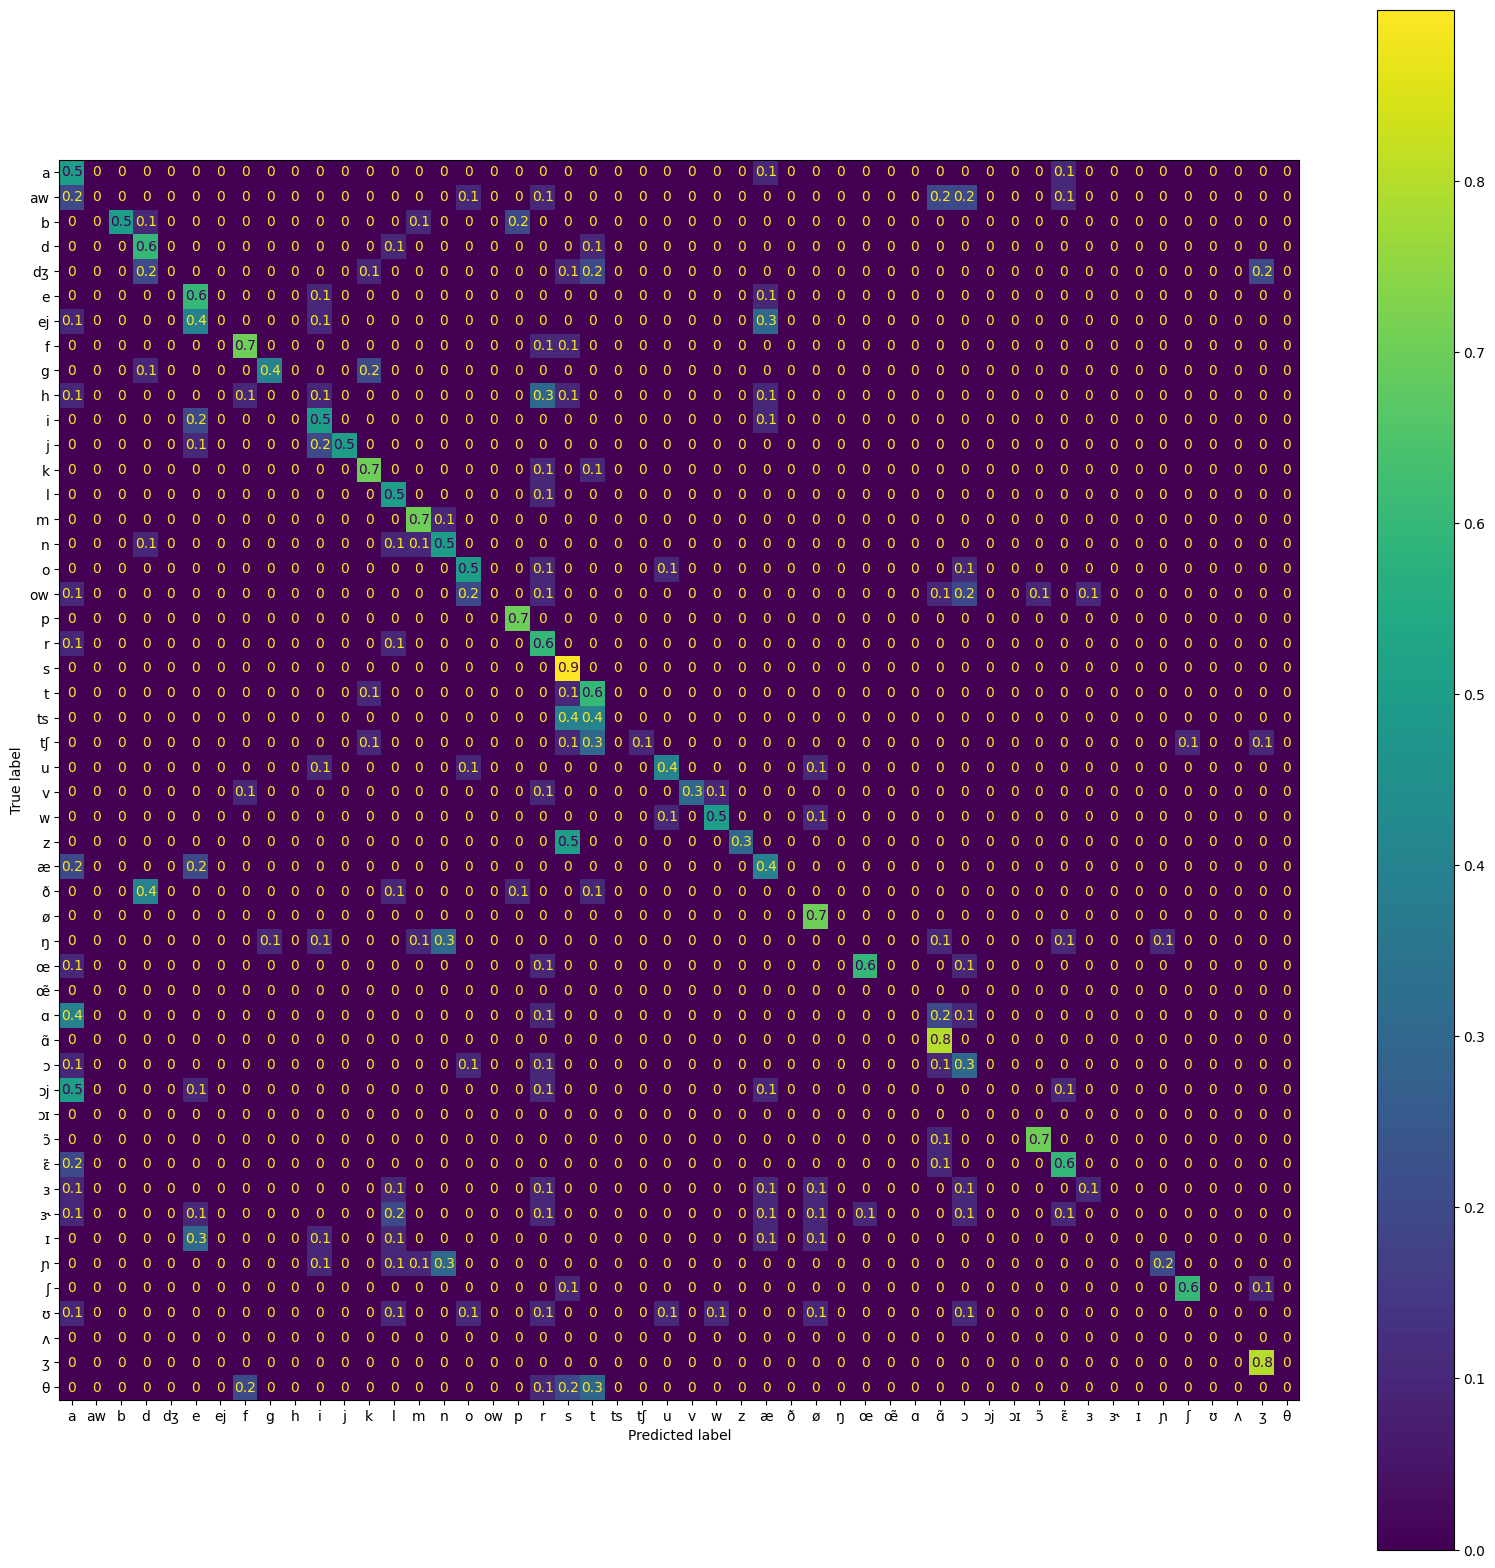

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (20, 20)
confusions = (frfr_confusions / (frfr_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=1)
disp = ConfusionMatrixDisplay(confusions[1:,1:], display_labels=list(phone_encoder.lab2ind)[1:])
disp.plot()
plt.show()

In [20]:
### JUST NASALS
nasals = ['ɑ̃', 'ɔ̃', 'ɛ̃']
confusions = (frfr_confusions / (frfr_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=3)
indexes = [phone_encoder.lab2ind[l] for l in nasals]
for nasal, accuracy in zip(nasals, confusions[indexes, indexes]):
    print(f"/{nasal}/ has accuracy {accuracy:.1%}")

/ɑ̃/ has accuracy 78.8%
/ɔ̃/ has accuracy 70.8%
/ɛ̃/ has accuracy 55.7%


In [21]:
fren_confusions = torch.load("bilingual_networks/results/20fr20en/confusions_test.txt")

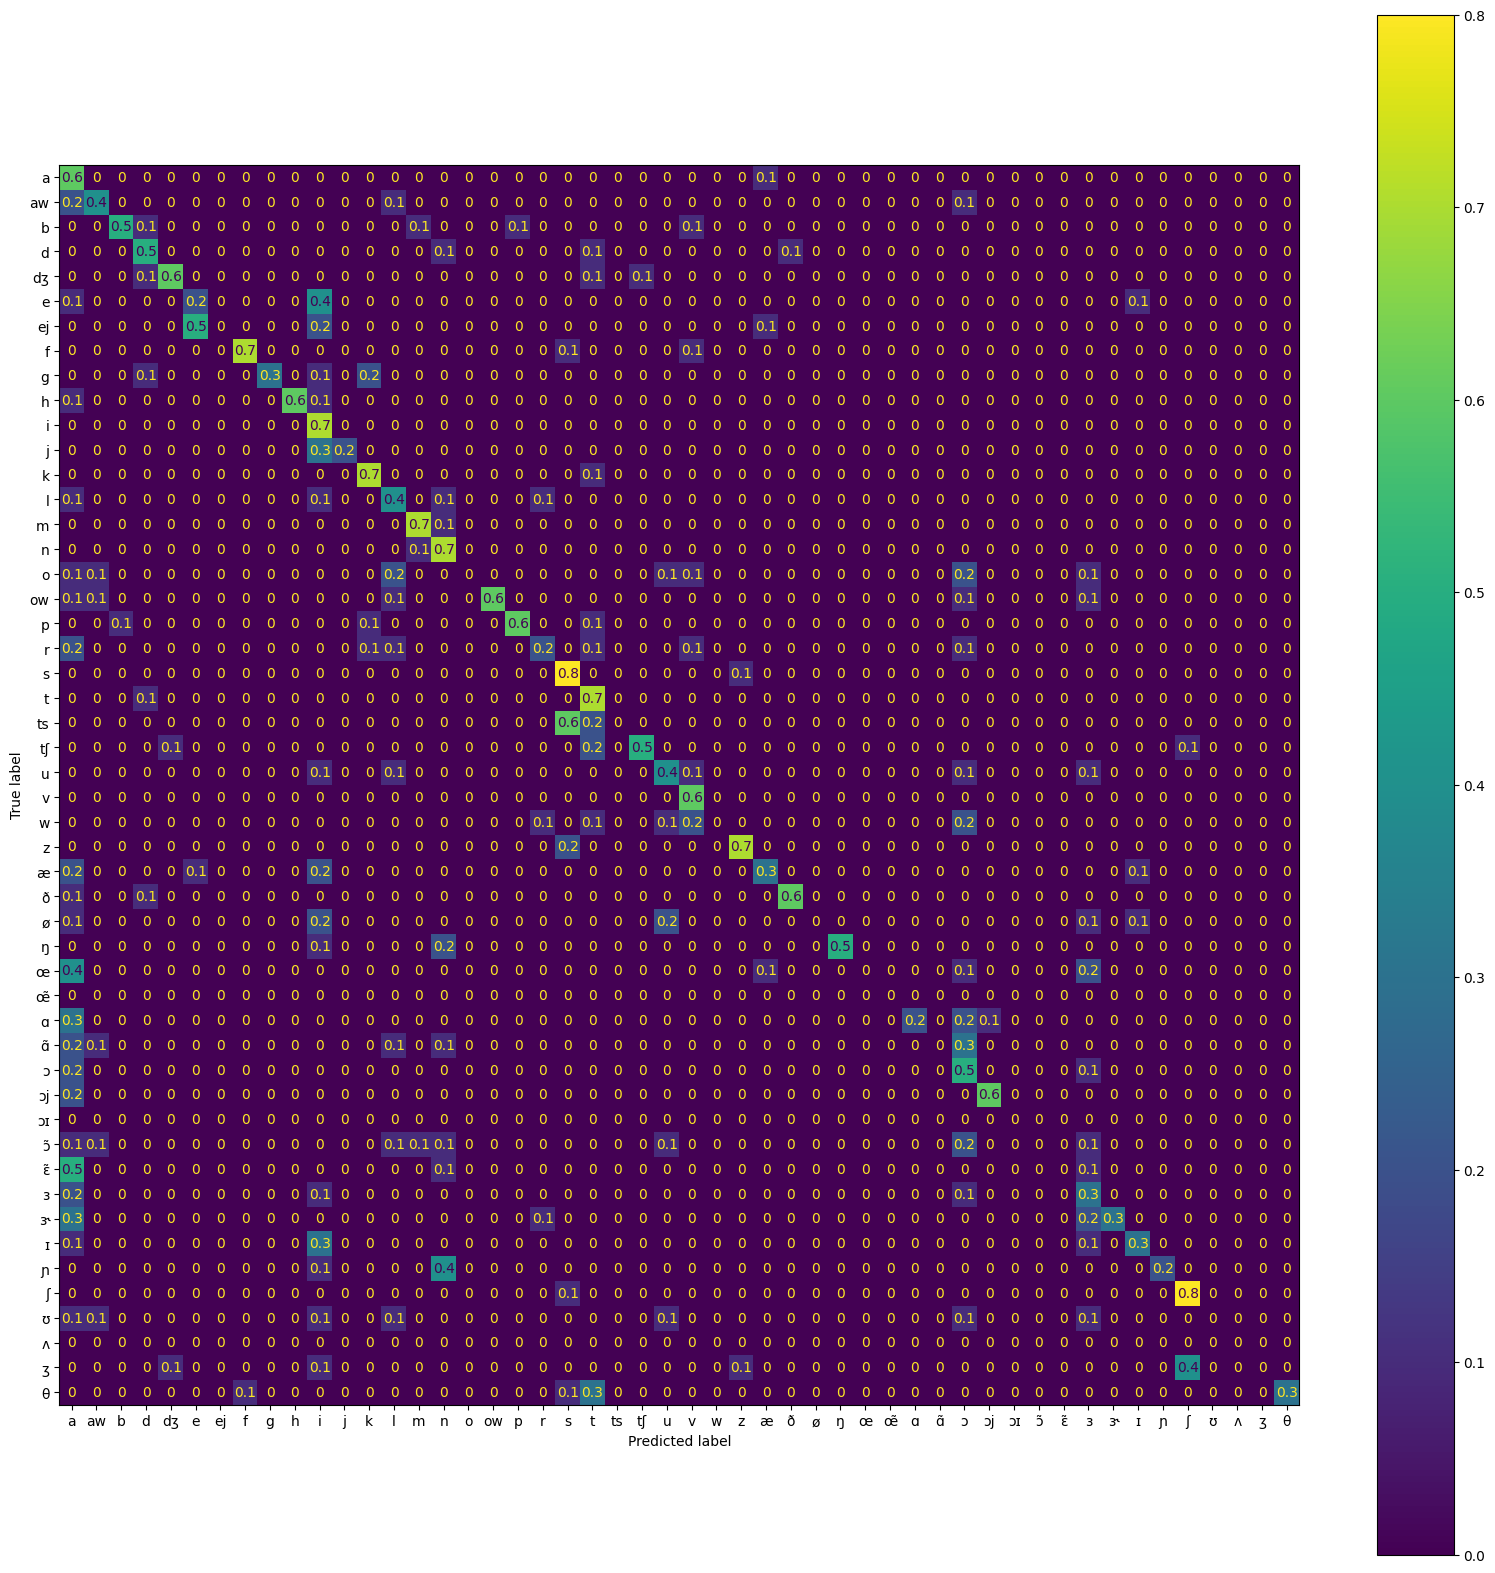

In [22]:
confusions = (fren_confusions / (fren_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=1)
disp = ConfusionMatrixDisplay(confusions[1:,1:], display_labels=list(phone_encoder.lab2ind)[1:])
disp.plot()
plt.show()

In [23]:
### JUST NASALS
nasals = ['ɑ̃', 'ɔ̃', 'ɛ̃']
confusions = (fren_confusions / (fren_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=3)
indexes = [phone_encoder.lab2ind[l] for l in nasals]
for nasal, accuracy in zip(nasals, confusions[indexes, indexes]):
    print(f"/{nasal}/ has accuracy {accuracy:.1%}")

/ɑ̃/ has accuracy 0.0%
/ɔ̃/ has accuracy 0.0%
/ɛ̃/ has accuracy 0.0%


In [24]:
frbi_confusions = torch.load("bilingual_networks/results/20fr20fr05en95/confusions_test.txt")

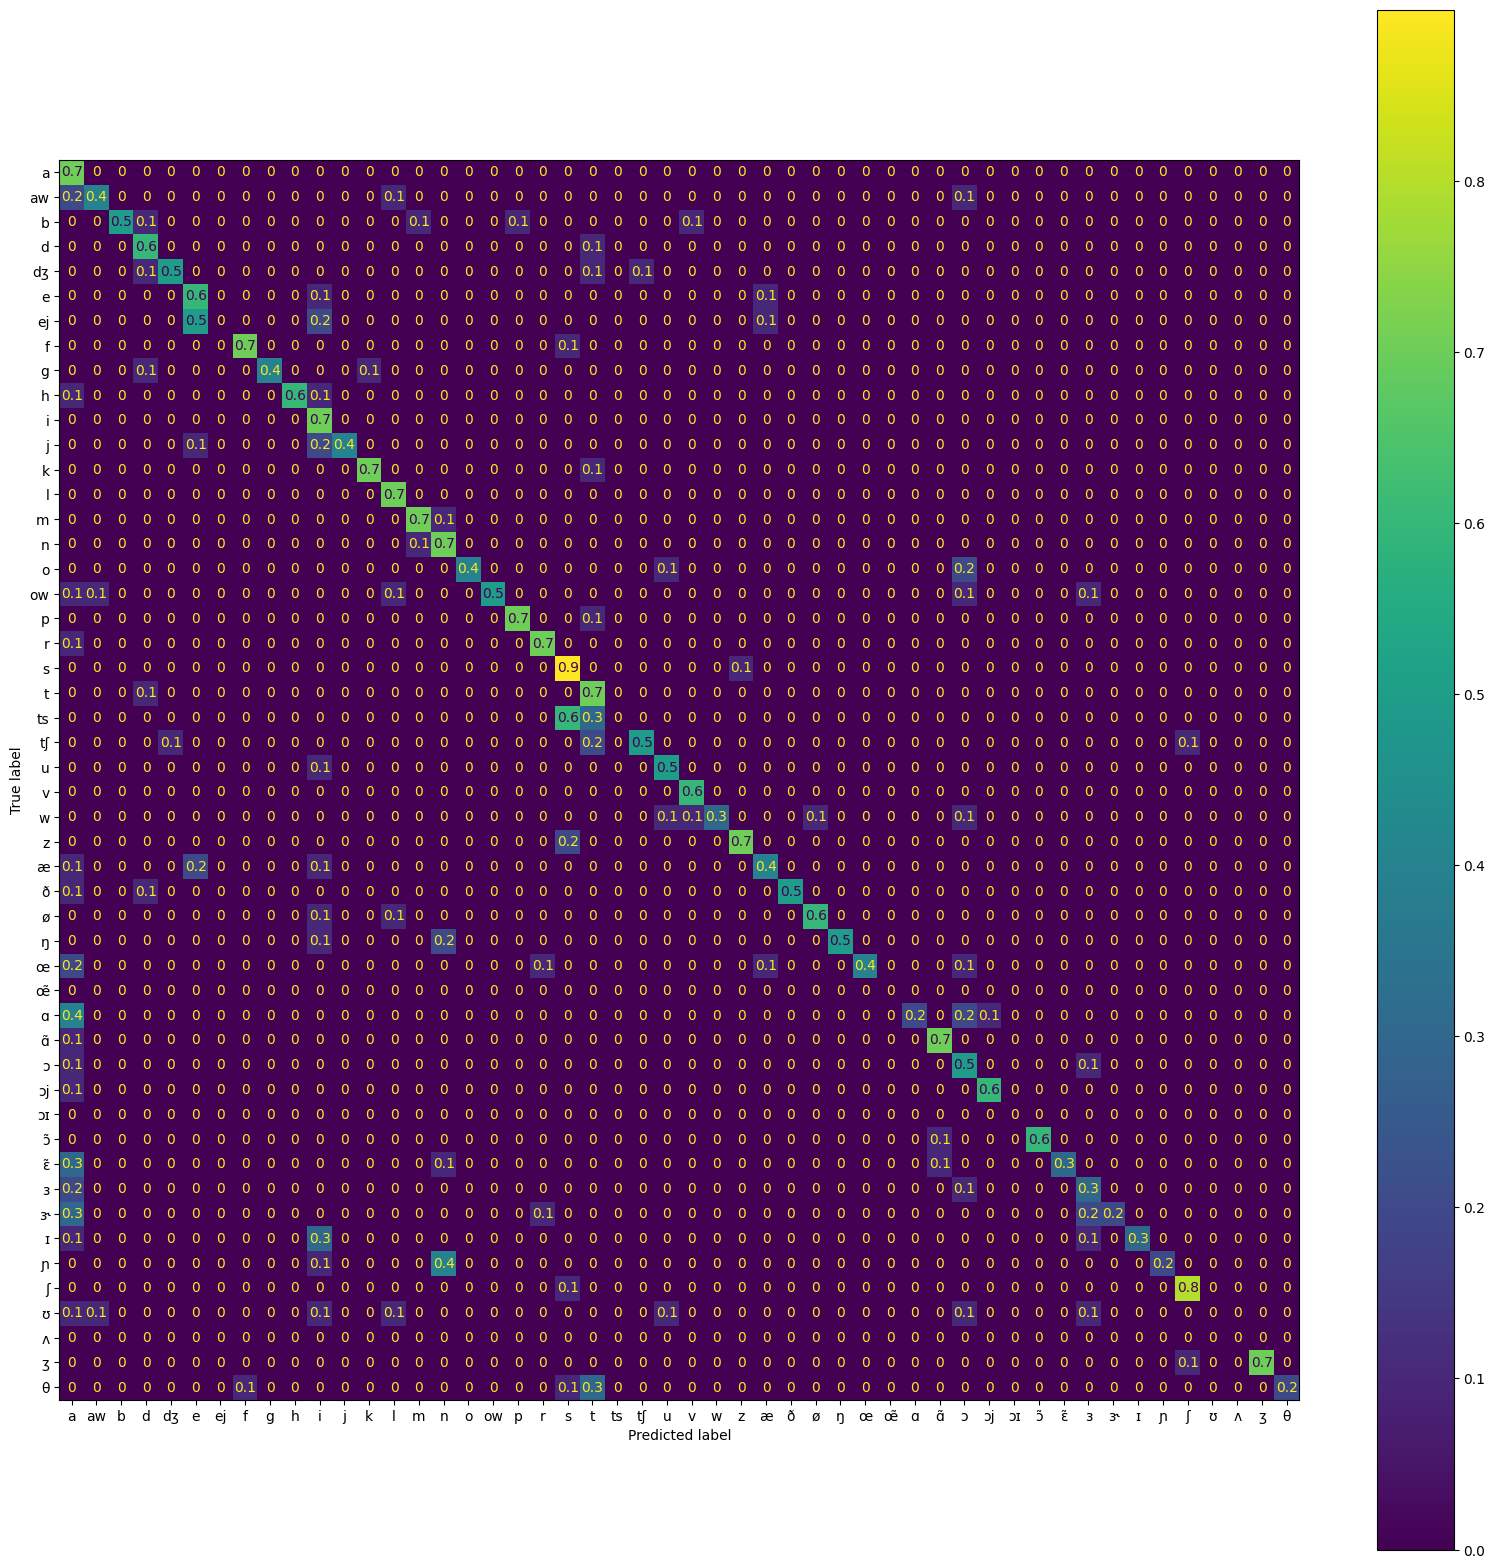

In [25]:
confusions = (frbi_confusions / (frbi_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=1)
disp = ConfusionMatrixDisplay(confusions[1:,1:], display_labels=list(phone_encoder.lab2ind)[1:])
disp.plot()
plt.show()

In [26]:
### JUST NASALS
nasals = ['ɑ̃', 'ɔ̃', 'ɛ̃']
confusions = (frbi_confusions / (frbi_confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=3)
indexes = [phone_encoder.lab2ind[l] for l in nasals]
for nasal, accuracy in zip(nasals, confusions[indexes, indexes]):
    print(f"/{nasal}/ has accuracy {accuracy:.1%}")

/ɑ̃/ has accuracy 70.3%
/ɔ̃/ has accuracy 59.7%
/ɛ̃/ has accuracy 31.8%


## Confusion Plots split by vowel-consonant

In [79]:
#monophthongs = ['a', 'æ', 'ɑ', 'ɑ̃', 'ʌ', 'ɔ', 'ɔ̃', 'ɛ', 'ɛ̃', 'ɜ', 'ɝ', 'ɪ', 'e', 'i', 'o', 'ø', 'œ', 'œ̃', 'u', 'ʊ']
monophthongs = ['a', 'ɑ', 'ɑ̃', 'ɔ', 'ɔ̃', 'ɛ', 'ɛ̃', 'ɜ', 'ɝ', 'ɪ', 'e', 'i', 'o', 'ø', 'œ', 'u']
consonants = ['b', 'p', 'f', 'v', 'w', 'ɡ', 'h', 'j', 'k', 'l', 'm', 'n', 'ŋ', 'ɲ',  'r', 's', 'z', 'd', 'dʒ', 'ʒ', 'ð', 'θ', 'ʃ', 't', 'tʃ']
vowel_rows = phone_encoder.encode_sequence(monophthongs)
conso_rows = phone_encoder.encode_sequence(consonants)
print(vowel_rows)

[1, 35, 36, 37, 40, 29, 41, 42, 43, 44, 6, 11, 17, 31, 33, 25]


In [102]:
import numpy as np

def plot_confusions(confusions, rows, labels, title_prefix=""):
    # Calculate appropriate figure size based on number of labels
    n_labels = len(labels)
    fig_size = max(6, n_labels * 0.4)  # Minimum 6 inches, scale with number of labels
    figure, ax = plt.subplots(figsize=(fig_size, fig_size))

    # Normalize by true label (dim 1) -- each true label adds up to 100% (across rows)
    confusions_pct = (confusions / (confusions.sum(dim=1, keepdim=True) + 1)).numpy().round(decimals=2) * 100

    # Select the specified rows/columns
    sub_confusions = confusions_pct[np.ix_(rows, rows)]
    disp = ConfusionMatrixDisplay(sub_confusions, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, im_kw={'vmax': 80})  # Disable default colorbar
    
    # Add colorbar with custom size
    plt.colorbar(disp.im_, ax=ax, fraction=0.0455, pad=0.04)
    plt.title(f"{title_prefix} Confusion Rates (%)")
    plt.show()

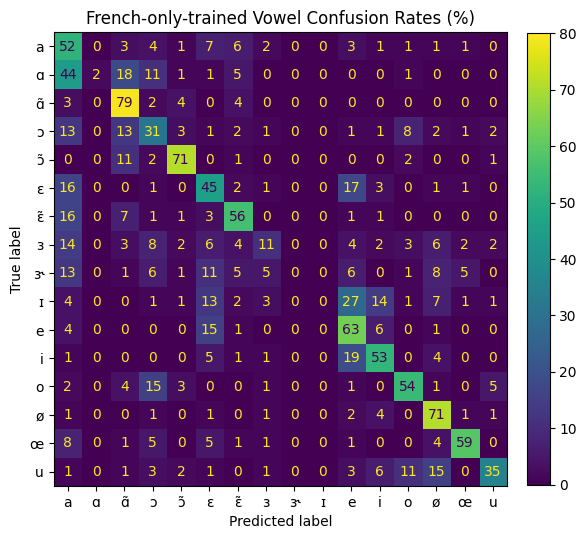

In [103]:
plot_confusions(frfr_confusions, vowel_rows, monophthongs, "French-only-trained Vowel")

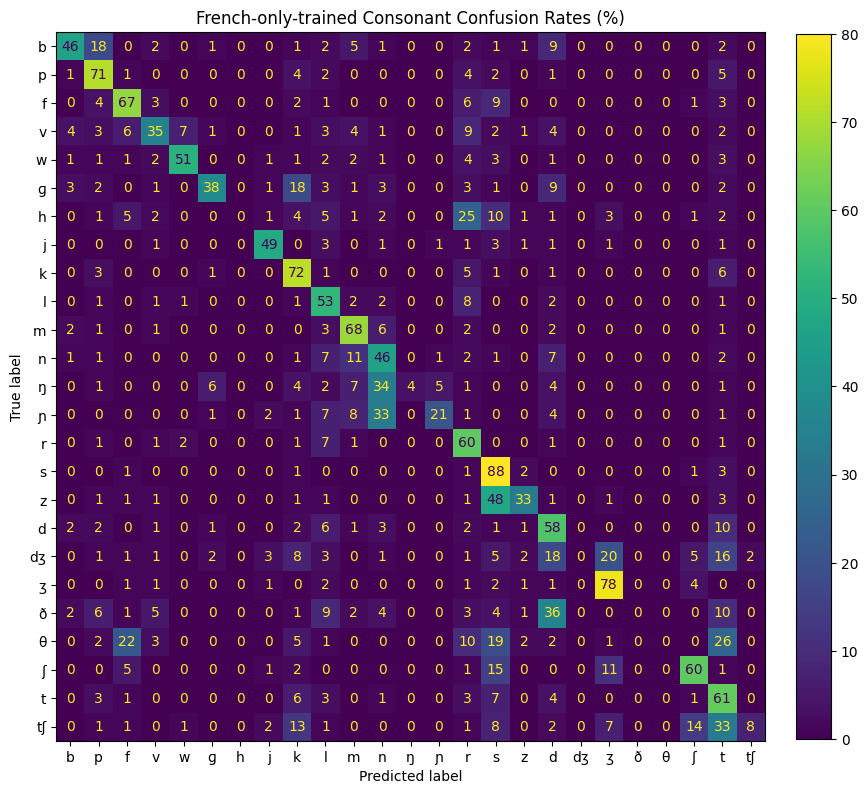

In [104]:
plot_confusions(frfr_confusions, conso_rows, consonants, "French-only-trained Consonant")

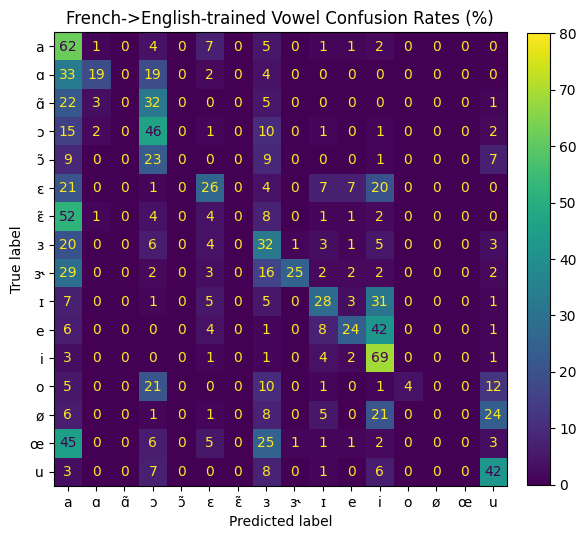

In [105]:
plot_confusions(fren_confusions, vowel_rows, monophthongs, "French->English-trained Vowel")

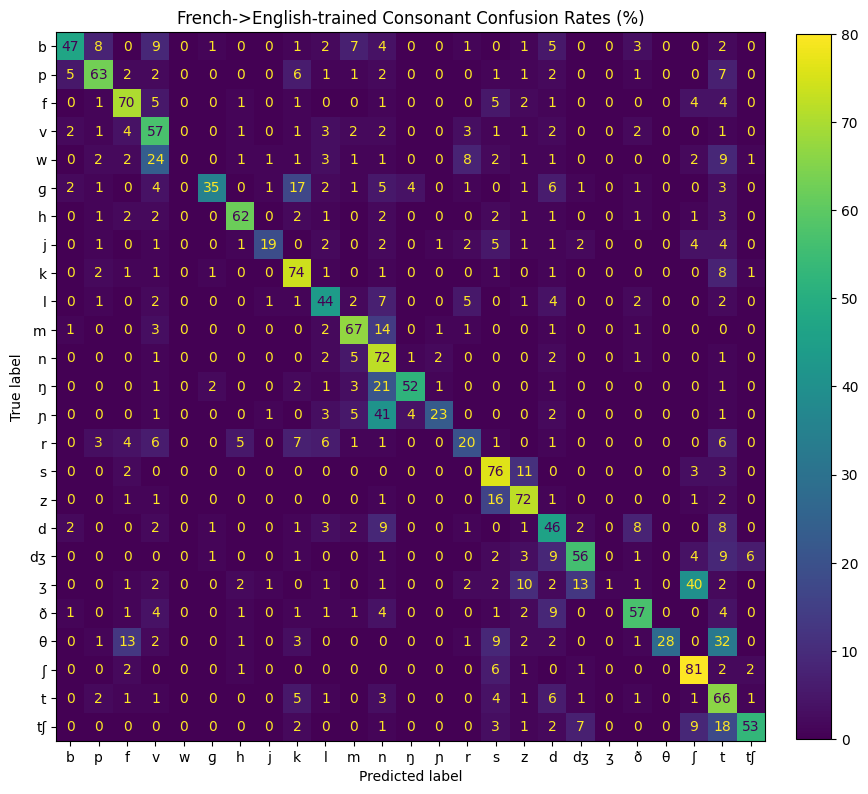

In [106]:
plot_confusions(fren_confusions, conso_rows, consonants, "French->English-trained Consonant")

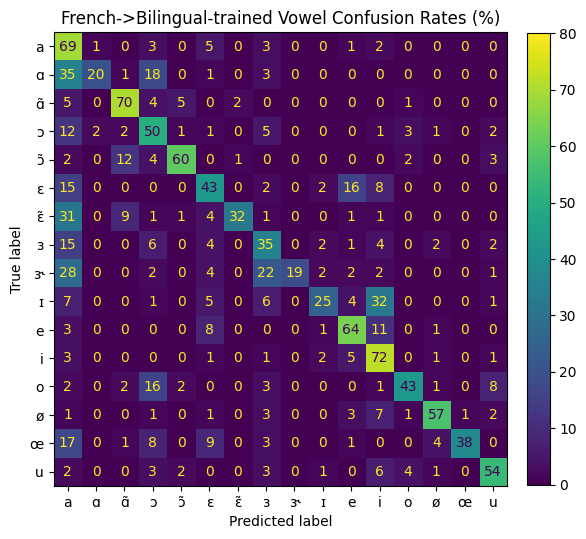

In [107]:
plot_confusions(frbi_confusions, vowel_rows, monophthongs, "French->Bilingual-trained Vowel")

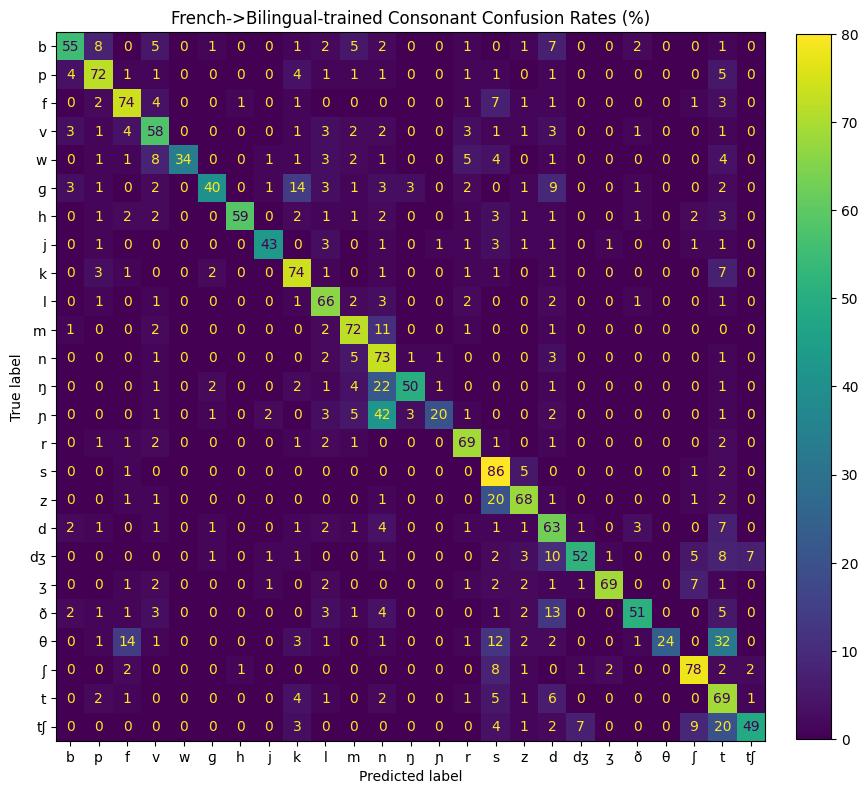

In [108]:
plot_confusions(frbi_confusions, conso_rows, consonants, "French->Bilingual-trained Consonant")